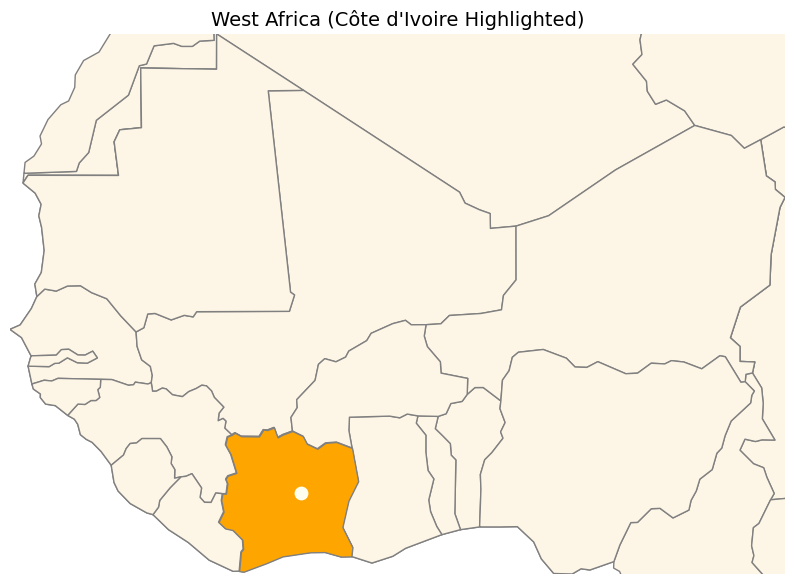

In [40]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Bouaké coordinates
lat = 7 + 41 / 60 + 46.6 / 3600
lon = -(5 + 1 / 60 + 56.4 / 3600)
bouake_point = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326")

# Load country outlines
world = gpd.read_file("shp/ne_110m_admin_0_countries.shp").to_crs(epsg=4326)

# Get all African countries
africa = world[world["CONTINENT"] == "Africa"]

# Define subsets
west_africa = africa[africa["SUBREGION"] == "Western Africa"]
civ = west_africa[west_africa["NAME"] == "Côte d'Ivoire"]

# Axis limits based on West Africa extents
xmin, ymin, xmax, ymax = west_africa.total_bounds

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all Africa light grey
africa.plot(ax=ax, color="oldlace", edgecolor="grey")

# Overlay West Africa slightly darker grey
west_africa.plot(ax=ax, color="oldlace", edgecolor="grey")

# Highlight Côte d'Ivoire
civ.plot(ax=ax, color="orange", edgecolor="grey")

# Add Bouaké
bouake_point.plot(ax=ax, color="ivory", markersize=80, zorder=5)

# Adjust axis limits so we only see West Africa region
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Layout
ax.set_title("West Africa (Côte d'Ivoire Highlighted)", fontsize=14)
ax.axis("off")

plt.savefig("west_africa_civ_context.png", format="png", dpi=300, bbox_inches="tight")
plt.show()